![alt text](uspas.png)
# Fundamentals of Accelerator Physics and Technology
### (with Simulations and Measurements Lab)
# Computer Lab: Transverse Dynamics
##### Author: M. Syphers, E. Harms, N. Neveu, K. Ruisard and N. Evans

This session deals with transverse dynamics in three sections. The first demonstrates the development evolution of a beam envelope by tracking a particle repeatedly through a thin lens FODO lattice. The second demonstrates the development of ellipses in phase space for the same FODO lattice. The third demonstrates the evolution of a local orbit distortion in a FODO lattice and how to correct it.

### Python Notes:
- Highlight a notebook cell and press Shift+Enter to execute, or use the play button at the top of the window.
- Make sure you execute notebook cells in order.  You must re-execute prior cells if you change something needed in a cell above where you are working.
- Repeated variables are appeneded with a number (1,2,3) indicating the section they belong to.
- You can also execute the whole notebook by using 'Run all cells' under the 'Run' tab.
- '2**2' represents two squared, i.e. 2^2
- A colon (:) means all values in that dimension. i.e. array[:,2] = all rows, second column
- You can change the plot limits by adjusting the numbers in 'plt.ylim()'
----------

In [1]:
### Run this cell to load needed packages
# Importing plotting library
import matplotlib
from matplotlib import pyplot as plt
#Setting resolution of plot (changes size too)
matplotlib.rcParams['figure.dpi'] = 100
from cycler import cycler
# Importing math library
import numpy as np


## 1. Betatron Oscillation Envelope

For transverse motion of a particle (beam) to be stable, the trace of the 2X2 transport matrix for each degree of freedom (horizontal and vertical) must be less than or equal to 2 in absolute value: |TrM| ≤2. For a simple FODO structure made up of thin-lens focusing elements (kicks of focal length ±F) separated by a drifts of distance L, the stability condition is equivalent to F ≥L/2.

In following cells, the FODO cell parameters are initially F = 8 meters and L = 10 meters. The worksheet shows eight half-cells, or four full FODO cells, and a particle with initial conditions $x_{0,0}$ and $x’_{0,0}$ is tracked through the system. The indices on the position $x_{i,j}$ are for the j-th passage through the i-th element of the structure. The number of turns begins with `N_turn= 1` and with $x_{0,0}= 5$ mm.
- Gradually increase `N_turn` to 2, 5, 10, 100 turns. While the particle starts out with a displacement of 5 mm, it ultimately reaches larger excursions as it evolves farther.

In [2]:
################################
# Don't change this cell
################################
def run_exercise1(N_turn1,N_hcell1,L1,F1):
    # Phase advance
    amp = L1/(2*F1)
    mu1 = 2*np.arcsin(amp)
    print('mu:', np.rad2deg(mu1))    ### page 35 in Eric's transverse motion lecture


    # Calclating
    nu1 = (N_hcell1*np.arcsin(L1/(2*F1)))/(2*np.pi)
    print('nu:', nu1)

    x1  = np.zeros((N_hcell1+2, N_turn1))
    xp1 = np.zeros((N_hcell1+2, N_turn1))
    s1  = np.zeros((N_hcell1+2, N_turn1))
    axp = np.zeros((N_hcell1+2, N_turn1)) ############

    # Initial conditions
    x1[0,0]  = 5e-3 # initial x displacement: 5 mm
    xp1[0,0] = 0    # initial xp: 0
    s1[0,0]  = 0    # initial s position: 0

    # Tracking through matrices
    for j in range(0,N_turn1):
        # Returning to s = 0, start of FODO
        if j>0:
            x1[0,j]  = x1[-1,j-1]
            xp1[0,j] = xp1[-1,j-1]
            s1[0,j]  = 0

        q1 = -1/F1 # Stability condition
        for i in range(0,N_hcell1+1):


            # -- first step is half drift
            if (i==N_hcell1):
                L = L1/2.
                q = 0.
            else:
                q1 *= -1 # flip sign every quad
                q = q1
                L = L1
            if (i==0):
                L = L1/2.

            # Calculating x
            x1[i+1,j]  = x1[i,j] + L*xp1[i,j]
            # Calculating x prime
            xp1[i+1,j] = xp1[i,j] + (x1[i,j]+xp1[i,j]*L)*q
            # Calculating s
            s1[i+1,j]  = s1[i,j] + L




    # Plotting the data
    print('max x value in plot:', max(x1[:,0]), 'm')
    plt.figure(figsize=[10,3])
    for p in range(0,N_turn1):
        plt.plot(s1[:,p],x1[:,p], '-', markersize=10,label='pass %i'%(p+1))
    plt.ylabel('x [m]', size=14)
    plt.xlabel('S [m]', size=14)
    plt.gca().set_xticks(np.arange(0,(N_hcell1+1)*10,10))
    plt.grid()
    if N_turn1 < 11:
        plt.legend(loc='upper left',bbox_to_anchor=(1,1))

    plt.show()

**Q1) What is the largest displacement that the particle can reach in the structure?**

**Q2) At what locations in $s$ are the focusing quadrupoles? Defocusing quadrupoles?**

**Q3) Where in the FODO structure i.e. at the F, D, or O (drift) does the maximum displacement occur?**

---
- Return to `N_turn=1`.
- Adjust the focal length, `F1`, until the parameter $\mu = 90^{\circ}$.
- Change the number of half-cells to `N_hcell1= 20`.

**Q4) For what value of `F1` does $\mu=90^{\circ}$? How many full cells (20 meter units) does it take for the pattern to repeat itself?**

This is the point where the particle has made one full oscillation in $x$, which corresponds to moving $360^{\circ}$ around the phase-space ellipse.

**Q5) For what value of `F1` does $\mu=60^{\circ}$? How many full cells (20 meter units) does it take for the orbit pattern to repeat itself?**

**Q6) Interpret the particle phase advance $\mu$?**

---

Typically we think that stronger quadrupoles will provide better focusing, meaning a smaller transverse beam where the bundle of all particles has a smaller extent from the ideal orbit (machine axis). This works up to the stability threshold. If the quadrupoles become too strong, then the particle orbits will be unstable and the bundle of orbit excursions will increase. In a thin-lens FODO lattice, instability appears when when |TrM| > 2, or equivalently, when F < L/2. Here TrM is the trace of the transport matrix M. Recall that F is the quadrupole focal length; smaller F corresponds with stronger quadrupole focusing. We will set the quadrupole focal length slightly below the stability limit to visualize the instability.
- Leaving the other parameters alone, set `F1 = L1/2 - 0.001`

**Q7) If the radius of a cylindrical vacuum chamber is 10 centimeters, and initially the particle is centered on the axis of this chamber, how far will the particle travel before it reaches the chamber wall? Give answer in meters and in number of full FODO cells.** Hint: you may need to adjust `N_hcell1` to find where this condition is met.

**Q8) Try reducing F even further below the stability limit F < L/2. Try `F1 = L1/2 - 0.1` and `F1 = L1/2 - 0.2`. What happens to the particle trajectory? (Does the particle amplitude grow faster, slower or remain the same?)**

---

/tmp/ipykernel_61893/860337096.py:7: RuntimeWarning: invalid value encountered in arcsin
  mu1 = 2*np.arcsin(amp)
/tmp/ipykernel_61893/860337096.py:12: RuntimeWarning: invalid value encountered in arcsin
  nu1 = (N_hcell1*np.arcsin(L1/(2*F1)))/(2*np.pi)


mu: nan
nu: nan
max x value in plot: 0.17859249058237825 m


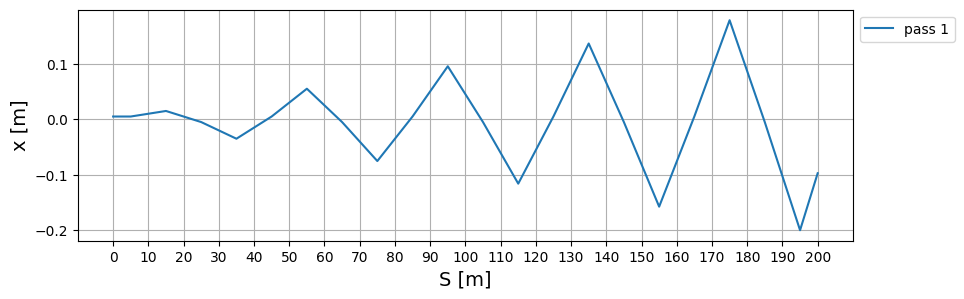

In [3]:
################################
# Change parameters in this cell
################################

#Number of turns and half cells
N_turn1  = 1 # inital turns: 1
N_hcell1 = 20 # initial half cells: 8

#Defining some variables
#These will be used later
L1       = 10  # distance between quadrupoles. initial: 10 meters
F1       = 4.999  # focal length of quadrupole lense. initial: 8 meters

run_exercise1(N_turn1,N_hcell1,L1,F1)

## 2. Betatron Oscillations in Phase Space

The two plots below are a correlated trajectory plot and a phase space plot. As the particle passes through the thin-lens FODO lattice, its position $x$ and angle $x'$ are kept track of and plotted in the phase space plot. Phase space coordinates just before and after each focusing kick are plotted. For `N_turn= 1`, follow compare the labeled points to understand how the lines in the two plots are related to one another. A change in slope on the phase space plot corresponds to a “kink” seen in the trajectory plot, etc. *Note that the locations of the quadrupole magnets in $s$ are shifted by 5 meters compared to the plots in Part 1.*
- Change `N_turn` to 2, 5, 10, 20 and 50, and examine how the two plots change.

**Q9) With `N_turn=50`, print out or make a sketch of this phase space plot and identify each ellipse with its corresponding quadrupole (F or D) and whether it is at the entrance or exit of the magnet.**

These phase space ellipses represent the "Courant-Snyder" invariant of the particle motion in the thin-lens FODO lattice. The ellipse is quadratic in $x-x'$ and has constant area, but changes orientation (rotation and aspect ratio) with location ($s$) within the lattice consistent with the lattice functions $\beta(s)$ and $\alpha(s)$. The particle is constrained to move along this ellipse. This constant area in $x-x'$ phase-space is described by the quantity *emittance.*


In [4]:
#################################
# Do not change this cell
#################################

def run_exercise2(N_turn1,N_hcell2,F2,L2,plot_single_location):

    # Phase advance per cell
    amp2 = L2/(2*F2)
    mu2  = 2*np.arcsin(amp2)
    print('mu:', np.rad2deg(mu2))

    # Tune for whole lattice
    nu2 = (N_hcell2/2) * mu2/(2*np.pi)
    print('nu:', nu2)

    # Making data holders
    x2  = np.zeros((N_hcell2*2+1, N_turn2))
    xp2 = np.zeros((N_hcell2*2+1, N_turn2))
    s2  = np.zeros((N_hcell2*2+1, N_turn2))

    # Initial conditions
    x2[0,0]  = 0.004 # initial x position = 4 mm
    xp2[0,0] = 0     # iniital xp = 0
    s2[0,0]  = 0     # initial s position = 0 m

    # Tracking through matrices
    for j in range(0,N_turn2):
        # Setting s back to 0 m (start of FODO)
        if j>0:
            x2[0,j] = x2[-1,j-1]
            xp2[0,j] = xp2[-1,j-1]
            s2[0,j]  = 0
        for i in range(0,N_hcell2*2):
            #Accounting for drift
            z = i+1
            zm = z%2
            if zm==1:
                q2 = 0
                d2 = L2
            else:
                q2 = ((-1)**((i+3)/2))*(1/F2)
                d2 = 0

            # Calculating x
            x2[i+1,j]  = x2[i,j] + d2*xp2[i,j]
            # Calculating x prime
            xp2[i+1,j] = xp2[i,j] + (x2[i,j]+xp2[i,j]*d2)*q2
            # Calculating s
            s2[i+1,j]  = s2[i,j] + d2

    # -- small difference in s for purpose of plotting;
    # only if plotting first turn
    if N_turn2==1:
        for i in range(np.shape(s2)[0]):
            s2[i,:] -= -.5 + 1*np.mod(i,2)

    n = (N_turn2 if N_turn2 > 1 else np.shape(x2)[0])
    color = plt.cm.hsv(np.linspace(0.1,0.9,n)) # This returns RGBA; convert:
    custom_cycler = (cycler(color=color))

    ##################
    # Trajectory plot
    ##################
    plt.figure(figsize=[12,4])
    plt.subplot(121)
    plt.gca().set_prop_cycle(custom_cycler)

    # there is different behavior for 1st turn plot
    if N_turn2 == 1:
        plt.plot(s2[:,0],x2[:,0]*10**3, '-k', markersize=1,alpha=.2)
        for point in range(np.shape(x2)[0]):
            plt.plot(s2[point,0],x2[point,0]*10**3, '.', markersize=10)
    else:
        for p2 in range(0,N_turn2):
            plt.plot(s2[:,p2],x2[:,p2]*10**3, '-', markersize=1,label='turn %i'%(p2+1))
        # -- only plot legend for small number of turns, 2<=N_turn2<=15
        if N_turn2 < 15:
            plt.legend(bbox_to_anchor=(1,1),loc='upper left')

    plt.ylabel('x [mm]', size=14)
    plt.xlabel('S [m]', size=14)
    plt.title('Trajectory plot')
    plt.grid()

    ##################
    # Phase space plot
    ##################
    plt.subplot(122)
    plt.gca().set_prop_cycle(custom_cycler)

    # this determines if we should plot all locations or just 1
    if plot_single_location:
        idx_plot = [0]
        plot_title = 'Phase space plot at s=%.1f m'%s2[idx_plot,0]
    else:
        idx_plot = range(np.shape(s2)[0])
        plot_title = 'Phase space plot, all points'

    # there is different behavior for 1st turn plot
    if N_turn2 ==1:
        plt.plot(x2[idx_plot ,0]*10**3,xp2[idx_plot ,0]*10**3, '-k',alpha=.2)
        for point in idx_plot:
            plt.plot(x2[point,0]*10**3,xp2[point,0]*10**3, '.', markersize=10)
    else:
        plt.plot(x2[idx_plot ,:].T.flatten()*10**3,xp2[idx_plot ,:].T.flatten()*10**3, '-k',alpha=.05)
        for turn in range(0,N_turn2):
            plt.plot(x2[idx_plot ,turn]*10**3,xp2[idx_plot ,turn]*10**3, '.', markersize=10)

    plt.ylabel('xp [mrad]', size=14)
    plt.xlabel('x [mm]', size=14)
    plt.title(plot_title)

    plt.grid(False)
    plt.tight_layout()
    plt.show()

mu: 77.36437490697888
nu: 0.8596041656330987


/tmp/ipykernel_61893/4214511050.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plot_title = 'Phase space plot at s=%.1f m'%s2[idx_plot,0]


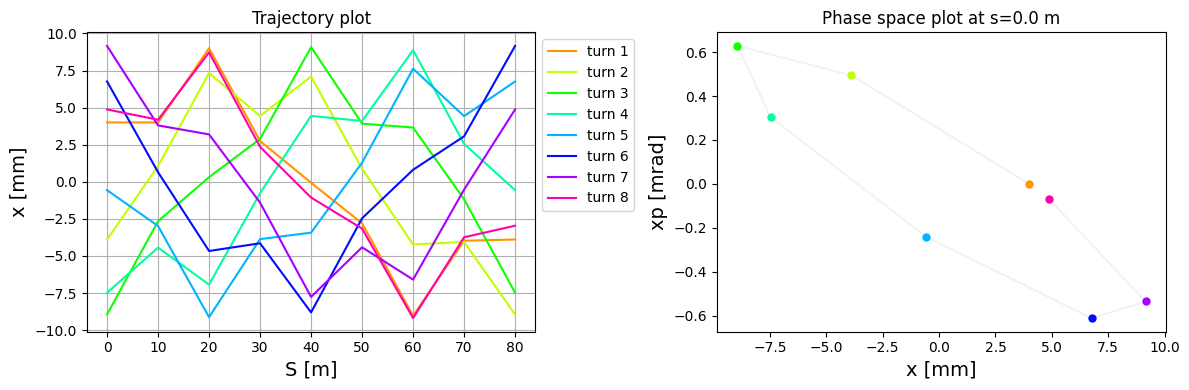

In [5]:
################################
# Change parameters in this cell
################################

N_turn2  = 8 # initial turns = 1
plot_single_location = True # toggle
# whether to plot all locations in s
# on phase space plot, or just s=0


# These variables don't need to be changed
# to do the exercise:

# quadrupole focal length
F2  = 8  # initial = 8 m
# half cell length
L2  = 10  # initial = 10 m
# Number of half cells
N_hcell2 = 8 # initial cells = 8

# execute script
run_exercise2(1,N_hcell2,F2,L2,plot_single_location)



By examining the particle advance in $x$-$x'$ phase-space at one location in our lattice (we'll pick the spot right after the focusing quad at s=0), we can also calculate the tune `nu`. However, since this plot is blind to interger numbers of full oscillations that might occur over a turn, we are only sensitive to the *fractional* part of `nu`, which we'll call `nu_f`. This is a common situation in accelerator measurements, where we often have limited diagnostic locations.

- Set `plot_single_location = True`. This will change the phase space plot so that we are only viewing the particle trajectory as it crosses s=0.
- Slowly increase `N_turn2` in steps of 1 until the trajectory makes 1 turn around the phase space ellipse (it won't be exact, so pick the nearest point).

**Q10) Using the phase space plot, estimate the value of the fractional tune `nu_f`. Recall tune is the number of revolutions in phase space per turn. Also calculate `1 - nu_f` and record both values. Which is closer to the value of `nu` calculated (see output above plot)?** The formula used to calculate `nu` above is from the thin lens approximation of a FODO cell, $\nu = N_{cell} \cdot \frac{\mu}{2\pi}$, where $\mu = \arcsin{\frac{L}{2F}}$. The phase advance per cell $\mu$ is multiplied by the number of FODO cells $N_{cell}$ and divided by $2\pi$ to obtain $\nu$.

**Q11) Explain why, using the information from the single-location phase space plot, it is impossible to differentiate between `nu=nu_f` and `nu=1-nu_f`. What leads to this ambiguity?**


mu: 77.36437490697888
nu: 0.8596041656330987


/tmp/ipykernel_61893/4214511050.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plot_title = 'Phase space plot at s=%.1f m'%s2[idx_plot,0]


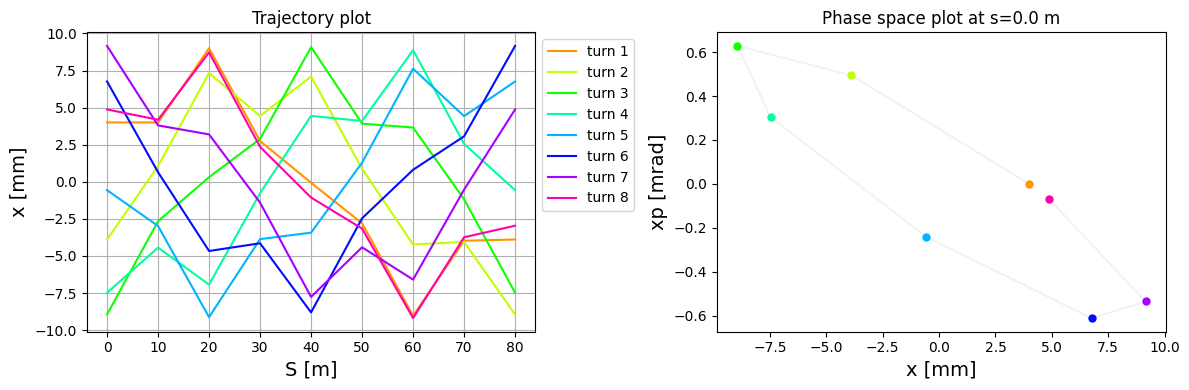

In [6]:
run_exercise2(100,N_hcell2,F2,L2,plot_single_location)

---
## 3. Closed Orbit Error & Correction

Today’s final exercise will be to look at how we can correct for a local orbit distortion. For this exercise, we will change our FODO lattice parameters to F = 20 meters and L  = 25 meters. At a specific location in the lattice ($s=10$ meters), there is an additional element: a dipole steering error which gives the particle an angular deflection kick $\theta$ each time the particle passes. By looking at the plot of particle displacement, we see that although the particle starts on the ideal orbit (x = 0 and x’ = 0), it begins a betatron oscillation after it passes the steering error kick (note the SOLID trace in the plot). This steering error can be caused by an improperly set steering magnet or by a mechanically mis-aligned quadrupole magnet (displaced quadrupole gives a dipole + quadrupole). There are also some scenarios in which a steering "error" is introduced intentionally. For example,  the beam may be steered off-axis to place the beam on a diagnostic that is out of the way of the normal beam path or to help kick the beam out of the ring.

Even in the presence of steering kicks, there is a particular trajectory which, at the end of 1 turn, will have the same position and slope/angle as at the start of the turn. This particular trajectory is known as the *closed orbit*, meaning a particle on this trajectory will follow the same path over and over again on every sequential turn. All other orbits will oscillate about the closed orbit. In the absence of steering errors, the ideal closed orbit goes through the center of all quadrupoles ($x = 0$ and $x’ = 0$).
- Change $N_{turn}$ from 1 to 2, 5, 10, 100.
- Notice how the particle appears to oscillate about the new closed orbit generated by the steering magnet.

Even though the magnet only steers the particle at one specific location in the accelerator lattice, it can affect the displacement everywhere.


In [7]:
#################################
# Do not change this cell
#################################
def run_exercise3(N_turn3,N_hcell3,F3,L3,theta_1,theta_2,theta_3,plot_average_flag):

    # Locations of the correctors
    z1       = 10 # initial = 10 th element
    z2       = 14 # initial = 14 th element
    z3       = 16 # initial = 16 th element

    # Calculating
    nu3 = (N_hcell3*np.arcsin(L3/(2*F3)))/(2*np.pi)
    print('nu: ', nu3)
    x3  = np.zeros((N_hcell3+1,N_turn3))
    xp3 = np.zeros((N_hcell3+1, N_turn3))
    s3  = np.zeros((N_hcell3+1, N_turn3))

    # Initial conditions
    x3[0,0]  = 0.0 # initial x position = 0 m
    xp3[0,0] = 0 # initial xp = 0 mrad

    # Tracking through matrices
    for j in range(0,N_turn3):
        # Setting s back to 0 m (start of FODO)
        if j>0:
            x3[0,j]  = x3[-1,j-1]
            xp3[0,j] = xp3[-1,j-1]
            s3[0,j]  = 0
        for i in range(0,N_hcell3):
                #
                q3 = ((-1)**(i+2))*(1/F3)
                # Calculating x
                x3[i+1,j]  = x3[i,j] + L3*xp3[i,j]
                # Calculating x prime
                if i == z1-1:
                    theta = theta_1
                elif i == z2-1:
                    theta = theta_2
                elif i ==z3-1:
                    theta = theta_3
                else:
                    theta = 0
                xp3[i+1,j] = xp3[i,j] + (x3[i,j]+xp3[i,j]*L3)*q3 + theta
                # Calculating s
                s3[i+1,j]  = s3[i,j] + L3

    # Plotting the data
    plt.figure(3)
    plt.plot(s3[:,0],x3[:,0]*10**3, '-', markersize=1,linewidth=2,color='grey',label='particle trajectory')
    for p3 in range(1,N_turn3):
        plt.plot(s3[:,p3],x3[:,p3]*10**3, '-', markersize=1,linewidth=0.5,color='grey')
    if plot_average_flag == True:
        plt.plot(s3[:,0],x3.mean(axis=1)*10**3,'k--',linewidth=2,color='red',label='Average of plotted trajectory')

    # -- kickers
    z = [z1,z2,z3]; names = ['error element','corrector 1', 'corrector 2']; colors = ['C0','C1','C1']
    yl = plt.ylim()
    for i in range(3):
        plt.plot([L3*z[i],L3*z[i]],yl,color=colors[i])
        plt.text(L3*z[i]-20,yl[0]+.3,names[i],rotation=90)

    plt.ylabel('x [mm]', size=14)
    plt.xlabel('S [m]', size=14)
    plt.legend(loc='upper left',bbox_to_anchor=(0,-.2))

    plt.grid(axis='y')
    plt.show()

nu:  2.149010414082747


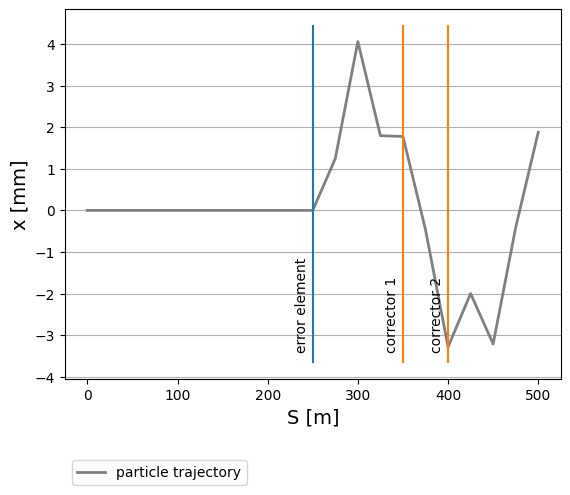

In [8]:
################################
# Change parameters in this cell
################################

N_turn3  = 1  # initial = 1
plot_average_flag = False

#Angles in milliradians
theta_1 = 0.05e-3 # initial = 0.05 mrad
theta_2 = 0   # initial = 0 mrad
theta_3 = 0  # initial = 0 mrad

# These variables don't need to be changed
# to do the exercise:

# quad focal length
F3       = 20  # initial = 20 m
# half cell length
L3       = 25  # initial = 25 m
# Number of half cells
N_hcell3 = 20 # initial = 20

# run script
run_exercise3(N_turn3,N_hcell3,F3,L3,theta_1,theta_2,theta_3,plot_average_flag)

In the presence of a particular steering error, the corresponding closed orbit can be calculated by averaging orbits over a large number of turns. Note that the average does not necessarily equal the closed orbit for a small number of turns.

- Set `plot_average_flag = True` to view the average of all plotted turns.
- increase `Nturn_3` until sufficiently large to allow the average trajectory to approach the closed orbit.


**Q12) What steering error, $\theta_1$ would generate a ~25 mm (1 inch) maximum displacement of the *closed orbit* in the beam pipe?** Hint: Be careful! The closed orbit displacement is NOT the particle displacement! Remember, a particle on the closed orbit will follow the same path every turn, while all other particles oscillate about the closed orbit.




---
Suppose we cannot tolerate such large orbit deviations and wish to restore the closed orbit to ($x=0$, $x'=0$). We can correct for the steering error by adding corrector magnets to create what is often called an *orbit bump*. Only near the location of the error will the closed orbit deviate from the ideal orbit, and after the correction the closed orbit will be restored to the machine center-line ($x=0$, $x'=0$). A minimum of two correctors are needed. Their locations are already indicated on the plot, but the strength of the correction kicks are initially set to zero. For purposes of illustrating this procedure:
- Restore the setting `theta_1 = 0.05e-3`.
- Return to plotting only the first turn, by setting `N_turn3 = 1`.

**Q13) Propose a general procedure for setting these two correctors to restore the orbit to $x=0$ and $x'=0$ after the second corrector.** Hint: Remember that a steering magnet can only change the trajectory angle.


Consistent with your procedure, carefully adjust the strengths of the two correctors (`theta_2` and `theta_3`) so that a particle whose trajectory starts with $x = 0$, $x’ = 0$ before the steering error kick ends up with $x = 0$ and $x’ = 0$ after corrector 2. Check the success of your *orbit bump* by setting `N_turn3` to some large value to verify that the orbit indeed repeats itself.

**Q14) With `theta_1 = 0.05e-3`, what values of `theta_2` and `theta_3` are required to bring the trajectory back to $x = 0$ and $x' = 0$?**


mu: nan
nu: nan
max x value in plot: 57270197148.692604 m


/tmp/ipykernel_61893/860337096.py:7: RuntimeWarning: invalid value encountered in arcsin
  mu1 = 2*np.arcsin(amp)
/tmp/ipykernel_61893/860337096.py:12: RuntimeWarning: invalid value encountered in arcsin
  nu1 = (N_hcell1*np.arcsin(L1/(2*F1)))/(2*np.pi)


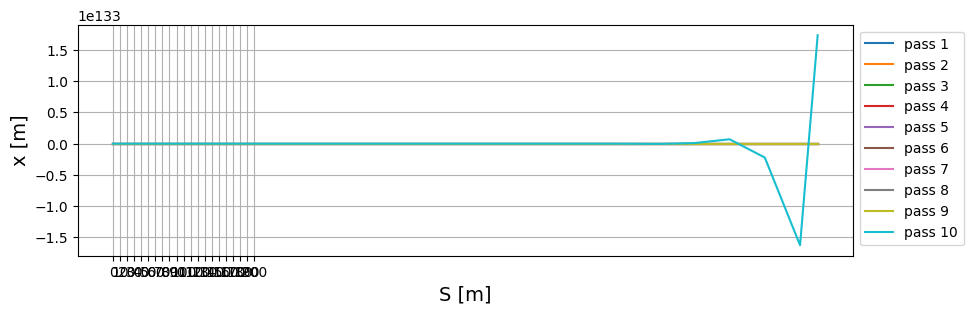

In [9]:
################################
# Change parameters in this cell
################################

#Number of turns and half cells
N_turn1  = 10 # inital turns: 1
N_hcell1 = 20 # initial half cells: 8

#Defining some variables
#These will be used later
L1       = 50  # distance between quadrupoles. initial: 10 meters
F1       = 10  # focal length of quadrupole lense. initial: 8 meters

run_exercise1(N_turn1,N_hcell1,L1,F1)